# E2 — Which credit-assignment rule actually works?

HLD §9.2 divides an outcome's credit among recalled memories **in proportion to
activation share**. That is a plausible-sounding choice with no evidence behind it.
This notebook tests it against the alternatives on identical traces.

| Rule | Description |
|---|---|
| `uniform` | every recalled memory gets 1/n — the null hypothesis |
| `activation` | proportional to activation share — the HLD default |
| `rank` | 1/log₂(rank+2), ignoring activation magnitude |
| `citation` | all credit to memories the agent reported using (`used_memories`) |

`citation` is the interesting one. It requires agent cooperation, so the HLD marks it
opt-in. If it is worth a lot, that field should be promoted from "nice to have" to
the primary integration ask — and the MCP tool descriptions should demand it.

In [1]:
import sys, warnings, math
from pathlib import Path
from dataclasses import replace

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import reverie
from reverie.sim import World, WorldConfig, run_trial, sweep, spearman, rank_metrics

# Publication styling: one place, so every figure in the paper matches.
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white",
})
# Colourblind-safe (Okabe-Ito), ordered so the first two are maximally distinct.
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png")
    fig.savefig(FIGDIR / f"{name}.pdf")
    print(f"wrote figures/{name}.png and .pdf")

SEEDS = 24          # seeds per configuration
print("reverie", reverie.__version__, "| numpy", np.__version__)

reverie 0.1.0.dev0 | numpy 2.5.1


In [2]:
def band(ax, df, x, y, hue=None, label=None, color=None):
    """Mean with a bootstrap 95% CI ribbon.

    Point estimates alone would overstate precision here: with a noisy agent
    and a couple of dozen seeds, curves that look separated frequently are not.
    """
    g = df.groupby(x)[y]
    mean = g.mean()
    lo = g.apply(lambda s: np.percentile(
        [np.mean(np.random.default_rng(i).choice(s.values, len(s))) for i in range(200)], 2.5))
    hi = g.apply(lambda s: np.percentile(
        [np.mean(np.random.default_rng(i).choice(s.values, len(s))) for i in range(200)], 97.5))
    ax.plot(mean.index, mean.values, marker="o", ms=3.5, lw=1.8, label=label, color=color)
    ax.fill_between(mean.index, lo.values, hi.values, alpha=0.15, color=color, lw=0)
    return mean

In [3]:
cfg = WorldConfig(n_memories=40, recall_size=6, relevance_p=0.5, cooccurrence=0.3)
CHECKPOINTS = [100, 200, 400, 800, 1600, 3200, 6400]
MODES = ["uniform", "activation", "rank", "citation"]

rows = []
for mode in MODES:
    for seed in range(SEEDS):
        for snap in run_trial(cfg, max(CHECKPOINTS), seed=seed,
                              credit_mode=mode, checkpoints=CHECKPOINTS):
            rows.append(snap.as_row(seed=seed))
df2 = pd.DataFrame(rows)
df2.groupby(["credit_mode", "n_recalls"])["spearman"].mean().unstack(0).round(3)

credit_mode,activation,citation,rank,uniform
n_recalls,,,,
100,0.132,0.072,0.091,0.046
200,0.142,0.120,0.117,0.079
400,0.218,0.153,0.185,0.148
800,0.291,0.264,0.269,0.223
1600,0.419,0.397,0.388,0.316
3200,0.525,0.483,0.477,0.405
6400,0.644,0.614,0.600,0.518


wrote figures/e2_credit_modes.png and .pdf


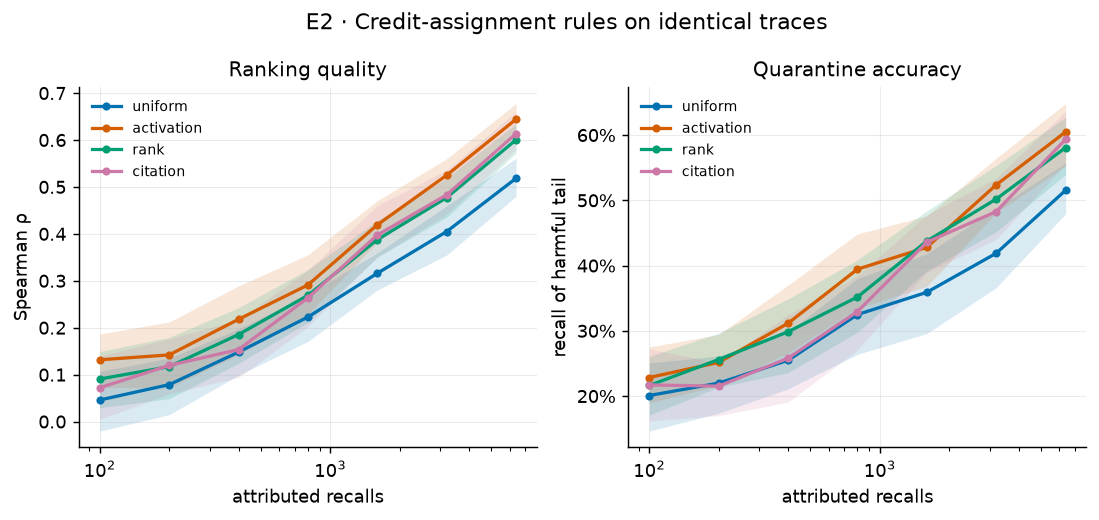

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for i, mode in enumerate(MODES):
    sub = df2[df2.credit_mode == mode]
    band(axes[0], sub, "n_recalls", "spearman", label=mode, color=PALETTE[i])
    band(axes[1], sub, "n_recalls", "worst_k_recall", label=mode, color=PALETTE[i])

axes[0].set_ylabel("Spearman ρ"); axes[0].set_title("Ranking quality")
axes[1].set_ylabel("recall of harmful tail"); axes[1].set_title("Quarantine accuracy")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel("attributed recalls"); ax.legend(fontsize=8)
fig.suptitle("E2 · Credit-assignment rules on identical traces", y=1.04)
save(fig, "e2_credit_modes")

## The value of an explicit citation

`citation` has access to the ground-truth relevance mask, so it is an **upper bound**
on what any credit rule can achieve — not an implementable estimator on its own, but
the right way to price the `used_memories` field. The gap between `activation` and
`citation` is what an integrator buys by populating it.

In [5]:
final = df2[df2.n_recalls == max(CHECKPOINTS)]
summary = final.groupby("credit_mode")[["spearman", "worst_k_recall"]].agg(["mean", "std"]).round(3)
display(summary)

base = final[final.credit_mode == "activation"]["spearman"].mean()
print(f"\nrelative to the HLD default (activation, ρ={base:.3f}):")
for mode in MODES:
    if mode == "activation":
        continue
    v = final[final.credit_mode == mode]["spearman"].mean()
    print(f"  {mode:<11} {v:+.3f}  ({(v-base)/abs(base)*100:+.0f}%)")

spearman        worst_k_recall       
                mean    std           mean    std
credit_mode                                      
activation     0.644  0.088          0.605  0.129
citation       0.614  0.105          0.593  0.117
rank           0.600  0.084          0.581  0.126
uniform        0.518  0.101          0.515  0.105


relative to the HLD default (activation, ρ=0.644):
  uniform     +0.518  (-20%)
  rank        +0.600  (-7%)
  citation    +0.614  (-5%)


wrote figures/e2_by_relevance.png and .pdf


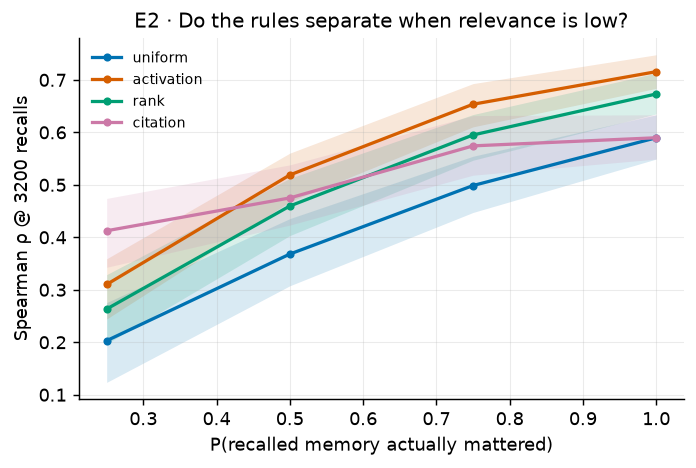

In [6]:
# Does the ranking of rules hold as relevance degrades? A rule that only wins in
# the easy regime is not worth the complexity.
rows = []
for rp in [0.25, 0.5, 0.75, 1.0]:
    c = replace(cfg, relevance_p=rp)
    for mode in MODES:
        for seed in range(16):
            snap = run_trial(c, 3200, seed=seed, credit_mode=mode)
            rows.append(snap.as_row(relevance_p=rp, seed=seed))
df_rp = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 3.6))
for i, mode in enumerate(MODES):
    band(ax, df_rp[df_rp.credit_mode == mode], "relevance_p", "spearman",
         label=mode, color=PALETTE[i])
ax.set_xlabel("P(recalled memory actually mattered)"); ax.set_ylabel("Spearman ρ @ 3200 recalls")
ax.set_title("E2 · Do the rules separate when relevance is low?")
ax.legend(fontsize=8)
save(fig, "e2_by_relevance")

## Findings

Record the measured verdict here. The decision this notebook drives:

- **If `activation` ≈ `uniform`:** the activation weighting in HLD §9.2 is
  complexity with no payoff and should be simplified away. Simpler is better when
  the evidence is neutral.
- **If `citation` ≫ `activation`:** `used_memories` is the highest-leverage field in
  the episode contract, and the SDK/MCP surface should be redesigned around getting
  it populated by default rather than treating it as optional.